# MONK Dataset Experiments

This notebook presents a comparative study of different machine learning models 
(k-NN, SVM, and MLP) on the MONK benchmark datasets.

We evaluate model performance, perform hyperparameter tuning, and analyze learning curves. 

The MONK experiments are used as a benchmark check before the CUP task, as required by the project guidelines. A fixed random_state is used to make train/test splits and model initialization reproducible.

Since the OpenML version provides the full dataset without predefined splits, a reproducible train/test split is created using random_state=42.

In [1]:
# Core libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

# Scikit-learn modules
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score


# Suppress MLP convergence warnings for cleaner notebook output
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [2]:
# Define the MONK results directory relative to the project root
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
results_dir = os.path.join(project_root, "results", "monk")
os.makedirs(results_dir, exist_ok=True)

In [3]:
# Load the three MONK tasks from OpenML
monk1 = fetch_openml(data_id=333, as_frame=True)
monk2 = fetch_openml(data_id=334, as_frame=True)
monk3 = fetch_openml(data_id=335, as_frame=True)

# Extract features and targets
X1, y1 = monk1.data, monk1.target
X2, y2 = monk2.data, monk2.target
X3, y3 = monk3.data, monk3.target

print("MONK-1:", X1.shape, y1.shape)
print("MONK-2:", X2.shape, y2.shape)
print("MONK-3:", X3.shape, y3.shape)



MONK-1: (556, 6) (556,)
MONK-2: (601, 6) (601,)
MONK-3: (554, 6) (554,)


In [4]:
print("\nMONK-1 sample:")
print(X1.head())
print(y1.head())
print(y2.value_counts())


MONK-1 sample:
  attr1 attr2 attr3 attr4 attr5 attr6
0     1     1     1     1     3     1
1     1     1     1     1     3     2
2     1     1     1     3     2     1
3     1     1     1     3     3     2
4     1     1     2     1     2     1
0    1
1    1
2    1
3    1
4    1
Name: class, dtype: category
Categories (2, object): ['0', '1']
0    395
1    206
Name: class, dtype: int64


In [5]:
print("\nMONK-2 sample:")
print(X2.head())
print(y2.head())
print(y2.value_counts())


MONK-2 sample:
  attr1 attr2 attr3 attr4 attr5 attr6
0     1     1     1     1     2     2
1     1     1     1     1     4     1
2     1     1     1     2     1     1
3     1     1     1     2     1     2
4     1     1     1     2     2     1
0    0
1    0
2    0
3    0
4    0
Name: class, dtype: category
Categories (2, object): ['0', '1']
0    395
1    206
Name: class, dtype: int64


In [6]:
# Inspect feature names and target labels
print("MONK-1 columns:", X1.columns.tolist())
print("MONK-1 target unique values:", sorted(y1.unique()))

print("MONK-2 columns:", X2.columns.tolist())
print("MONK-2 target unique values:", sorted(y2.unique()))

print("MONK-3 columns:", X3.columns.tolist())
print("MONK-3 target unique values:", sorted(y3.unique()))

MONK-1 columns: ['attr1', 'attr2', 'attr3', 'attr4', 'attr5', 'attr6']
MONK-1 target unique values: ['0', '1']
MONK-2 columns: ['attr1', 'attr2', 'attr3', 'attr4', 'attr5', 'attr6']
MONK-2 target unique values: ['0', '1']
MONK-3 columns: ['attr1', 'attr2', 'attr3', 'attr4', 'attr5', 'attr6']
MONK-3 target unique values: ['0', '1']


In [7]:
# Convert targets to integer labels
y1 = y1.astype(int)
y2 = y2.astype(int)
y3 = y3.astype(int)

print(y1.dtype, y2.dtype, y3.dtype)
print("MONK-1 labels:", sorted(y1.unique()))

int64 int64 int64
MONK-1 labels: [0, 1]


In [8]:
encoder1 = OneHotEncoder(handle_unknown="ignore")
encoder2 = OneHotEncoder(handle_unknown="ignore")
encoder3 = OneHotEncoder(handle_unknown="ignore")

X1_encoded = encoder1.fit_transform(X1)
X2_encoded = encoder2.fit_transform(X2)
X3_encoded = encoder3.fit_transform(X3)

Each MONK dataset is one-hot encoded separately using the standard 1-of-k representation. Since all MONK tasks share the same categorical attribute structure, this produces the expected 17-dimensional encoded input representation for each task.

In [9]:
# Print the shapes of the encoded datasets
print("MONK-1 encoded shape:", X1_encoded.shape)
print("MONK-2 encoded shape:", X2_encoded.shape)
print("MONK-3 encoded shape:", X3_encoded.shape)


MONK-1 encoded shape: (556, 17)
MONK-2 encoded shape: (601, 17)
MONK-3 encoded shape: (554, 17)


the encoding improves the accuracy because it creates a sparse matrix with a greater feature dimenson, by encodung all the numbers with 0 and 1

3 => [0, 0, 0, 1]

2 => [0, 0, 1]


## MONK-1 Baseline Experiments
We compare k-NN, SVM, and MLP on MONK-1 using a simple train-test split.

In [10]:
# Split data into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X1_encoded, y1, test_size=0.2, random_state=42, stratify=y1
)

# Train a k-NN classifier on MONK-1
# We use k=3 as a simple baseline model for comparison
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Predict class labels on the test set
y_pred = knn.predict(X_test)

# Compute classification accuracy on the test set
acc = accuracy_score(y_test, y_pred)

print("MONK-1 k-NN accuracy:", acc)

MONK-1 k-NN accuracy: 0.9017857142857143


In [11]:
# Train an SVM with RBF kernel as a non-linear baseline model
svm = SVC(kernel='rbf', C=1, gamma='scale')
svm.fit(X_train, y_train)

# Predict class labels on the test set
y_pred_svm = svm.predict(X_test)

# Compute classification accuracy on the test set
acc_svm = accuracy_score(y_test, y_pred_svm)

print("MONK-1 SVM accuracy:", acc_svm)

MONK-1 SVM accuracy: 1.0


In [12]:
# Train a small multilayer perceptron on MONK-1
# This neural model is included as a flexible non-linear baseline
mlp = MLPClassifier(hidden_layer_sizes=(3,), activation='relu',
                    max_iter=10000, random_state=42)

mlp.fit(X_train, y_train)

# Predict class labels on the test set
y_pred_mlp = mlp.predict(X_test)

# Compute classification accuracy on the test set
acc_mlp = accuracy_score(y_test, y_pred_mlp)

print("MONK-1 MLP accuracy:", acc_mlp)

MONK-1 MLP accuracy: 1.0


In [13]:
# Baseline comparison table for MONK-1
results_monk1 = pd.DataFrame({
    "Model": ["k-NN", "SVM", "MLP"],
    "Train Accuracy": [
        accuracy_score(y_train, knn.predict(X_train)),
        accuracy_score(y_train, svm.predict(X_train)),
        accuracy_score(y_train, mlp.predict(X_train))
    ],
    "Test Accuracy": [
        acc,
        acc_svm,
        acc_mlp
    ],
    "Test F1 Score": [
        f1_score(y_test, y_pred, average='weighted'),
        f1_score(y_test, y_pred_svm, average='weighted'),
        f1_score(y_test, y_pred_mlp, average='weighted')
    ]
})

print(results_monk1)

  Model  Train Accuracy  Test Accuracy  Test F1 Score
0  k-NN        0.959459       0.901786       0.901778
1   SVM        1.000000       1.000000       1.000000
2   MLP        1.000000       1.000000       1.000000


## MONK-1 Hyperparameter Tuning
In this section, we tune k-NN, SVM, and MLP hyperparameters using 5-fold cross-validation.

Best MONK-1 k-NN params: {'n_neighbors': 9}
Best MONK-1 k-NN CV score: 0.9572778345250255
MONK-1 k-NN Train Accuracy: 0.9932432432432432
MONK-1 k-NN Test Accuracy: 0.9910714285714286
Best MONK-1 SVM params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best MONK-1 SVM CV score: 1.0
MONK-1 SVM Train Accuracy: 1.0
MONK-1 SVM Test Accuracy: 1.0
Best MONK-1 MLP params: {'activation': 'logistic', 'alpha': 0.1, 'hidden_layer_sizes': (3,)}
Best MONK-1 MLP CV score: 1.0
MONK-1 MLP Train Accuracy: 1.0
MONK-1 MLP Test Accuracy: 1.0


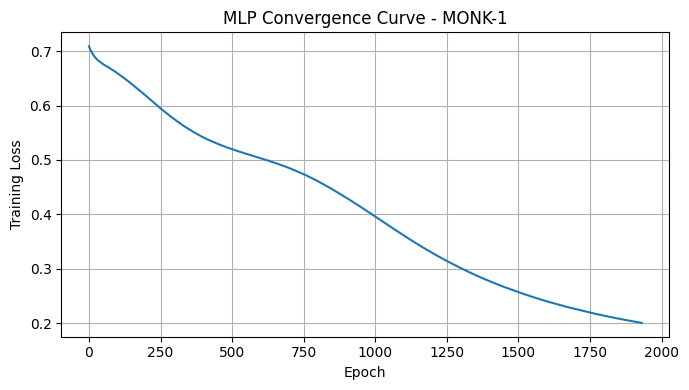

MONK-1 MLP Mean Test Accuracy: 0.8580
MONK-1 MLP Std Test Accuracy: 0.1013
  Model                                    Best Parameters  Best CV Accuracy
0  k-NN                                 {'n_neighbors': 9}          0.957278
1   SVM        {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}          1.000000
2   MLP  {'activation': 'logistic', 'alpha': 0.1, 'hidd...          1.000000
  Model  Train Accuracy  Test Accuracy  Best CV Accuracy  \
0  k-NN        0.993243       0.991071          0.957278   
1   SVM        1.000000       1.000000          1.000000   
2   MLP        1.000000       1.000000          1.000000   

                                     Best Parameters  MLP Mean Test Accuracy  \
0                                 {'n_neighbors': 9}                     NaN   
1        {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}                     NaN   
2  {'activation': 'logistic', 'alpha': 0.1, 'hidd...                0.858036   

   MLP Std Test Accuracy  
0                    NaN  
1

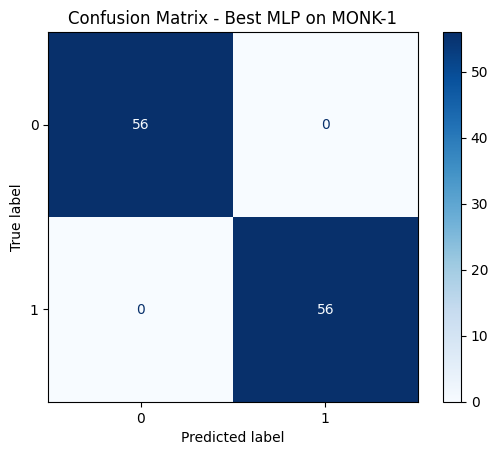

In [14]:
# Hold out final test set before hyperparameter tuning
X1_train_val, X1_test_final, y1_train_val, y1_test_final = train_test_split(
    X1_encoded, y1, test_size=0.2, random_state=42, stratify=y1
)

# ------------------------------------------------------------
# k-NN hyperparameter tuning for MONK-1
# ------------------------------------------------------------
param_grid_knn = {
    "n_neighbors": [1, 3, 5, 7, 9]
}

grid_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid_knn,
    cv=5,
    scoring="accuracy"
)

grid_knn.fit(X1_train_val, y1_train_val)

print("Best MONK-1 k-NN params:", grid_knn.best_params_)
print("Best MONK-1 k-NN CV score:", grid_knn.best_score_)

best_knn1 = grid_knn.best_estimator_

train_acc_knn1 = accuracy_score(y1_train_val, best_knn1.predict(X1_train_val))
test_acc_knn1 = accuracy_score(y1_test_final, best_knn1.predict(X1_test_final))

print("MONK-1 k-NN Train Accuracy:", train_acc_knn1)
print("MONK-1 k-NN Test Accuracy:", test_acc_knn1)


# ------------------------------------------------------------
# SVM hyperparameter tuning for MONK-1
# ------------------------------------------------------------
param_grid_svm = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.1, 1],
    "kernel": ["rbf"]
}

grid_svm = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid_svm,
    cv=5,
    scoring="accuracy"
)

grid_svm.fit(X1_train_val, y1_train_val)

print("Best MONK-1 SVM params:", grid_svm.best_params_)
print("Best MONK-1 SVM CV score:", grid_svm.best_score_)

best_svm1 = grid_svm.best_estimator_

train_acc_svm1 = accuracy_score(y1_train_val, best_svm1.predict(X1_train_val))
test_acc_svm1 = accuracy_score(y1_test_final, best_svm1.predict(X1_test_final))

print("MONK-1 SVM Train Accuracy:", train_acc_svm1)
print("MONK-1 SVM Test Accuracy:", test_acc_svm1)


# ------------------------------------------------------------
# MLP hyperparameter tuning for MONK-1
# ------------------------------------------------------------
param_grid_mlp = {
    "hidden_layer_sizes": [(2,), (3,), (4,)],
    "activation": ["logistic", "tanh", "relu"],
    "alpha": [0.0001, 0.001, 0.01, 0.1]
}

grid_mlp = GridSearchCV(
    estimator=MLPClassifier(max_iter=2000, random_state=42),
    param_grid=param_grid_mlp,
    cv=5,
    scoring="accuracy"
)

grid_mlp.fit(X1_train_val, y1_train_val)

print("Best MONK-1 MLP params:", grid_mlp.best_params_)
print("Best MONK-1 MLP CV score:", grid_mlp.best_score_)

best_mlp1 = grid_mlp.best_estimator_

train_acc_mlp1 = accuracy_score(y1_train_val, best_mlp1.predict(X1_train_val))
test_acc_mlp1 = accuracy_score(y1_test_final, best_mlp1.predict(X1_test_final))

print("MONK-1 MLP Train Accuracy:", train_acc_mlp1)
print("MONK-1 MLP Test Accuracy:", test_acc_mlp1)


# ------------------------------------------------------------
# Epoch-based convergence curve for MONK-1 MLP
# ------------------------------------------------------------
mlp_curve1 = MLPClassifier(
    **grid_mlp.best_params_,
    max_iter=2000,
    random_state=42
)

mlp_curve1.fit(X1_train_val, y1_train_val)

plt.figure(figsize=(7, 4))
plt.plot(mlp_curve1.loss_curve_)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("MLP Convergence Curve - MONK-1")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "monk1_mlp_convergence_curve.png"), dpi=300)
plt.show()



# ------------------------------------------------------------
# Multiple random initializations for MONK-1 MLP
# ------------------------------------------------------------
seeds = range(10)
mlp_accs1 = []

for seed in seeds:
    mlp_trial = MLPClassifier(
        **grid_mlp.best_params_,
        max_iter=2000,
        random_state=seed
    )
    mlp_trial.fit(X1_train_val, y1_train_val)
    y_pred_trial = mlp_trial.predict(X1_test_final)
    mlp_accs1.append(accuracy_score(y1_test_final, y_pred_trial))

mlp_mean_acc1 = np.mean(mlp_accs1)
mlp_std_acc1 = np.std(mlp_accs1)

print(f"MONK-1 MLP Mean Test Accuracy: {mlp_mean_acc1:.4f}")
print(f"MONK-1 MLP Std Test Accuracy: {mlp_std_acc1:.4f}")


# ------------------------------------------------------------
# Summary table for MONK-1 tuned models
# ------------------------------------------------------------
tuned_results_monk1 = pd.DataFrame({
    "Model": ["k-NN", "SVM", "MLP"],
    "Best Parameters": [
        grid_knn.best_params_,
        grid_svm.best_params_,
        grid_mlp.best_params_
    ],
    "Best CV Accuracy": [
        grid_knn.best_score_,
        grid_svm.best_score_,
        grid_mlp.best_score_
    ]
})

print(tuned_results_monk1)


# Final evaluation table for MONK-1 tuned models
monk1_tuned_eval = pd.DataFrame({
    "Model": ["k-NN", "SVM", "MLP"],
    "Train Accuracy": [
        train_acc_knn1,
        train_acc_svm1,
        train_acc_mlp1
    ],
    "Test Accuracy": [
        test_acc_knn1,
        test_acc_svm1,
        test_acc_mlp1
    ],
    "Best CV Accuracy": [
        grid_knn.best_score_,
        grid_svm.best_score_,
        grid_mlp.best_score_
    ],
    "Best Parameters": [
        grid_knn.best_params_,
        grid_svm.best_params_,
        grid_mlp.best_params_
    ],
    "MLP Mean Test Accuracy": [
        np.nan,
        np.nan,
        mlp_mean_acc1
    ],
    "MLP Std Test Accuracy": [
        np.nan,
        np.nan,
        mlp_std_acc1
    ]
})

print(monk1_tuned_eval)

## confusion matrix for the best MLP model on MONK-1
y_pred_mlp_best = best_mlp1.predict(X1_test_final)
cm_mlp1 = confusion_matrix(y1_test_final, y_pred_mlp_best)
disp_mlp1 = ConfusionMatrixDisplay(confusion_matrix=cm_mlp1)
disp_mlp1.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Best MLP on MONK-1")
plt.savefig(os.path.join(results_dir, "monk1_mlp_confusion_matrix.png"))
plt.show()

Both SVM and MLP achieve high performance on MONK-1, confirming that the task is simple enough for both nonlinear model families.

## MONK-1 Learning Curve (MLP)
We analyze how model performance changes with training size.

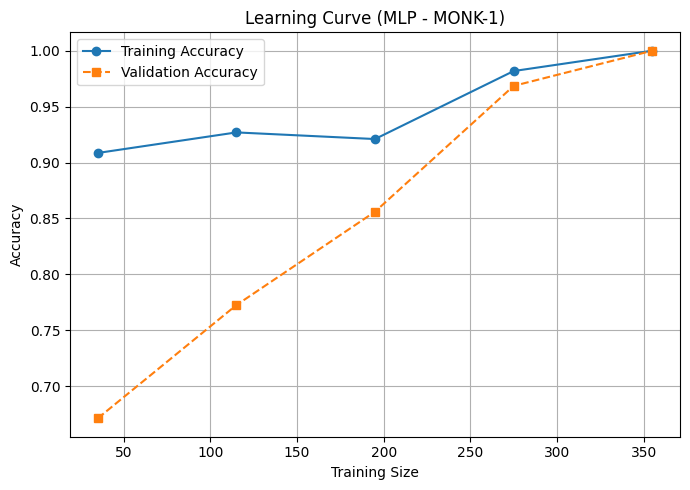

In [15]:
# Use best MLP configuration
mlp_best = best_mlp1

# Compute learning curve
train_sizes, train_scores, val_scores = learning_curve(
    mlp_best,
    X1_train_val, y1_train_val,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Compute mean scores
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

# Plot
plt.figure(figsize=(7, 5))
plt.plot(train_sizes, train_mean, marker="o", linestyle="-", label="Training Accuracy")
plt.plot(train_sizes, val_mean, marker="s", linestyle="--", label="Validation Accuracy")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve (MLP - MONK-1)")
plt.legend()
plt.grid()

# Save the learning curve figure to the results folder
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "monk1_learning_curve.png"), dpi=300)
plt.show()

### Interpretation

MONK-1 is a deterministic and low-complexity classification task. Since the target rule is clean and there is no label noise, both SVM with RBF kernel and a small MLP are expressive enough to learn the decision function.

The learning curve reaches high accuracy quickly, showing that model capacity is not the limiting factor. In this case, the task is close to a bias-variance trivial regime: the models are sufficiently flexible, and good generalization is expected.

## MONK-2 Baseline Experiments

In [16]:
# Use already encoded MONK-2 data
# Split data
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2_encoded, y2, test_size=0.2, random_state=42, stratify=y2
)

# Train a k-NN classifier on MONK-2 as a simple distance-based baseline
knn2 = KNeighborsClassifier(n_neighbors=3)
knn2.fit(X_train2, y_train2)
acc_knn2 = accuracy_score(y_test2, knn2.predict(X_test2))

# Train an SVM with RBF kernel on MONK-2 as a non-linear baseline
svm2 = SVC(kernel='rbf', C=1, gamma='scale')
svm2.fit(X_train2, y_train2)
acc_svm2 = accuracy_score(y_test2, svm2.predict(X_test2))

# Train a small multilayer perceptron on MONK-2 as a neural baseline
mlp2 = MLPClassifier(hidden_layer_sizes=(3,), max_iter=1000, random_state=42)
mlp2.fit(X_train2, y_train2)
acc_mlp2 = accuracy_score(y_test2, mlp2.predict(X_test2))

# Results
print("MONK-2 k-NN:", acc_knn2)
print("MONK-2 SVM:", acc_svm2)
print("MONK-2 MLP:", acc_mlp2)

# Baseline comparison table for MONK-2
results_monk2 = pd.DataFrame({
    "Model": ["k-NN", "SVM", "MLP"],
    "Train Accuracy": [
        accuracy_score(y_train2, knn2.predict(X_train2)),
        accuracy_score(y_train2, svm2.predict(X_train2)),
        accuracy_score(y_train2, mlp2.predict(X_train2))
    ],
    "Test Accuracy": [
        acc_knn2,
        acc_svm2,
        acc_mlp2
    ],
    "Test F1 Score": [
        f1_score(y_test2, knn2.predict(X_test2), average='weighted'),
        f1_score(y_test2, svm2.predict(X_test2), average='weighted'),
        f1_score(y_test2, mlp2.predict(X_test2), average='weighted')
    ]
})

print(results_monk2)

MONK-2 k-NN: 0.6694214876033058
MONK-2 SVM: 0.6198347107438017
MONK-2 MLP: 1.0
  Model  Train Accuracy  Test Accuracy  Test F1 Score
0  k-NN         0.87500       0.669421       0.669421
1   SVM         0.78125       0.619835       0.558153
2   MLP         1.00000       1.000000       1.000000


## MONK-2 Hyperparameter Tuning
We tune k-NN, SVM, and MLP on MONK-2 using 5-fold cross-validation.

Best MONK-2 k-NN params: {'n_neighbors': 1}
Best MONK-2 k-NN CV score: 0.675
MONK-2 k-NN Train Accuracy: 1.0
MONK-2 k-NN Test Accuracy: 0.743801652892562
Best MONK-2 SVM params: {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}
Best MONK-2 SVM CV score: 0.9958333333333332
MONK-2 SVM Train Accuracy: 1.0
MONK-2 SVM Test Accuracy: 1.0
Best MONK-2 MLP params: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (2,)}
Best MONK-2 MLP CV score: 1.0
MONK-2 MLP Train Accuracy: 1.0
MONK-2 MLP Test Accuracy: 1.0


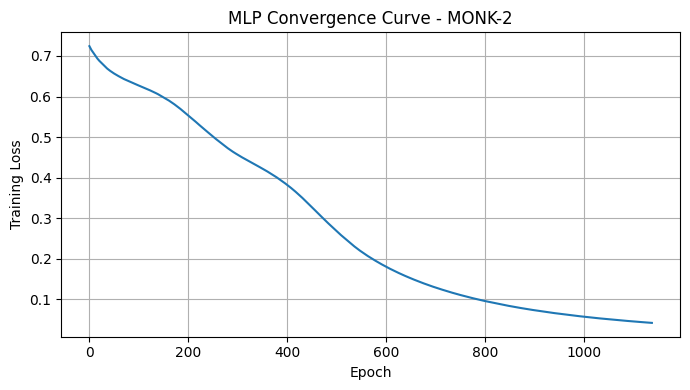

MONK-2 MLP Mean Test Accuracy: 0.7322
MONK-2 MLP Std Test Accuracy: 0.1119
  Model                                    Best Parameters  Best CV Accuracy
0  k-NN                                 {'n_neighbors': 1}          0.675000
1   SVM          {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}          0.995833
2   MLP  {'activation': 'relu', 'alpha': 0.0001, 'hidde...          1.000000
  Model  Train Accuracy  Test Accuracy  Best CV Accuracy  \
0  k-NN             1.0       0.743802          0.675000   
1   SVM             1.0       1.000000          0.995833   
2   MLP             1.0       1.000000          1.000000   

                                     Best Parameters  MLP Mean Test Accuracy  \
0                                 {'n_neighbors': 1}                     NaN   
1          {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}                     NaN   
2  {'activation': 'relu', 'alpha': 0.0001, 'hidde...                0.732231   

   MLP Std Test Accuracy  
0                    NaN  
1

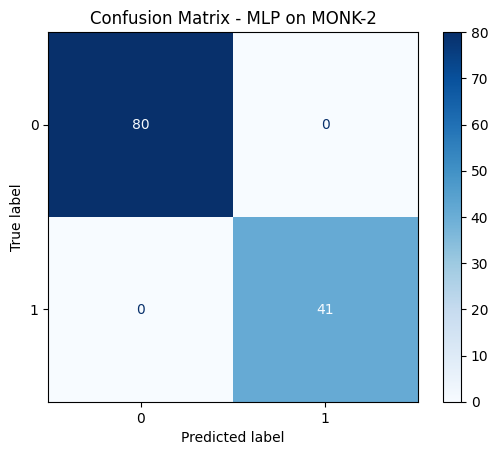

In [17]:
# Hold out final test set before hyperparameter tuning
X2_train_val, X2_test_final, y2_train_val, y2_test_final = train_test_split(
    X2_encoded, y2, test_size=0.2, random_state=42, stratify=y2
)

# ------------------------------------------------------------
# k-NN hyperparameter tuning for MONK-2
# ------------------------------------------------------------
param_grid_knn2 = {
    "n_neighbors": [1, 3, 5, 7, 9]
}

grid_knn2 = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid_knn2,
    cv=5,
    scoring="accuracy"
)

grid_knn2.fit(X2_train_val, y2_train_val)

print("Best MONK-2 k-NN params:", grid_knn2.best_params_)
print("Best MONK-2 k-NN CV score:", grid_knn2.best_score_)

best_knn2 = grid_knn2.best_estimator_

train_acc_knn2 = accuracy_score(y2_train_val, best_knn2.predict(X2_train_val))
test_acc_knn2 = accuracy_score(y2_test_final, best_knn2.predict(X2_test_final))

print("MONK-2 k-NN Train Accuracy:", train_acc_knn2)
print("MONK-2 k-NN Test Accuracy:", test_acc_knn2)


# ------------------------------------------------------------
# SVM hyperparameter tuning for MONK-2
# ------------------------------------------------------------
param_grid_svm2 = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.1, 1],
    "kernel": ["rbf"]
}

grid_svm2 = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid_svm2,
    cv=5,
    scoring="accuracy"
)

grid_svm2.fit(X2_train_val, y2_train_val)

print("Best MONK-2 SVM params:", grid_svm2.best_params_)
print("Best MONK-2 SVM CV score:", grid_svm2.best_score_)

best_svm2 = grid_svm2.best_estimator_

train_acc_svm2 = accuracy_score(y2_train_val, best_svm2.predict(X2_train_val))
test_acc_svm2 = accuracy_score(y2_test_final, best_svm2.predict(X2_test_final))

print("MONK-2 SVM Train Accuracy:", train_acc_svm2)
print("MONK-2 SVM Test Accuracy:", test_acc_svm2)


# ------------------------------------------------------------
# MLP hyperparameter tuning for MONK-2
# ------------------------------------------------------------
param_grid_mlp2 = {
    "hidden_layer_sizes": [(2,), (3,), (4,)],
    "activation": ["logistic", "tanh", "relu"],
    "alpha": [0.0001, 0.001, 0.01, 0.1]
}

grid_mlp2 = GridSearchCV(
    estimator=MLPClassifier(max_iter=2000, random_state=42),
    param_grid=param_grid_mlp2,
    cv=5,
    scoring="accuracy"
)

grid_mlp2.fit(X2_train_val, y2_train_val)

print("Best MONK-2 MLP params:", grid_mlp2.best_params_)
print("Best MONK-2 MLP CV score:", grid_mlp2.best_score_)

best_mlp2 = grid_mlp2.best_estimator_

train_acc_mlp2 = accuracy_score(y2_train_val, best_mlp2.predict(X2_train_val))
test_acc_mlp2 = accuracy_score(y2_test_final, best_mlp2.predict(X2_test_final))

print("MONK-2 MLP Train Accuracy:", train_acc_mlp2)
print("MONK-2 MLP Test Accuracy:", test_acc_mlp2)


# ------------------------------------------------------------
# Epoch-based convergence curve for MONK-2 MLP
# ------------------------------------------------------------
mlp_curve2 = MLPClassifier(
    **grid_mlp2.best_params_,
    max_iter=2000,
    random_state=42
)

mlp_curve2.fit(X2_train_val, y2_train_val)

plt.figure(figsize=(7, 4))
plt.plot(mlp_curve2.loss_curve_)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("MLP Convergence Curve - MONK-2")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "monk2_mlp_convergence_curve.png"), dpi=300)
plt.show()

## addtion of accuracy curve for MONK-2 MLP
train_acc_curve2 = mlp_curve2.validation_scores_ if hasattr(mlp_curve2, 'validation_scores_') else None
if train_acc_curve2 is not None:
    plt.figure(figsize=(7, 4))
    plt.plot(train_acc_curve2, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Validation Accuracy")
    plt.title("MLP Validation Accuracy Curve - MONK-2")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(results_dir, "monk2_mlp_validation_accuracy_curve.png"), dpi=300)
    plt.show()

# ------------------------------------------------------------
# Multiple random initializations for MONK-2 MLP
# ------------------------------------------------------------
seeds = range(10)
mlp_accs2 = []

for seed in seeds:
    mlp_trial = MLPClassifier(
        **grid_mlp2.best_params_,
        max_iter=2000,
        random_state=seed
    )
    mlp_trial.fit(X2_train_val, y2_train_val)
    y_pred_trial = mlp_trial.predict(X2_test_final)
    mlp_accs2.append(accuracy_score(y2_test_final, y_pred_trial))

mlp_mean_acc2 = np.mean(mlp_accs2)
mlp_std_acc2 = np.std(mlp_accs2)

print(f"MONK-2 MLP Mean Test Accuracy: {mlp_mean_acc2:.4f}")
print(f"MONK-2 MLP Std Test Accuracy: {mlp_std_acc2:.4f}")


# ------------------------------------------------------------
# Summary table for MONK-2 tuned models
# ------------------------------------------------------------
tuned_results_monk2 = pd.DataFrame({
    "Model": ["k-NN", "SVM", "MLP"],
    "Best Parameters": [
        grid_knn2.best_params_,
        grid_svm2.best_params_,
        grid_mlp2.best_params_
    ],
    "Best CV Accuracy": [
        grid_knn2.best_score_,
        grid_svm2.best_score_,
        grid_mlp2.best_score_
    ]
})

print(tuned_results_monk2)


# Final evaluation table for MONK-2 tuned models
monk2_tuned_eval = pd.DataFrame({
    "Model": ["k-NN", "SVM", "MLP"],
    "Train Accuracy": [
        train_acc_knn2,
        train_acc_svm2,
        train_acc_mlp2
    ],
    "Test Accuracy": [
        test_acc_knn2,
        test_acc_svm2,
        test_acc_mlp2
    ],
    "Best CV Accuracy": [
        grid_knn2.best_score_,
        grid_svm2.best_score_,
        grid_mlp2.best_score_
    ],
    "Best Parameters": [
        grid_knn2.best_params_,
        grid_svm2.best_params_,
        grid_mlp2.best_params_
    ],
    "MLP Mean Test Accuracy": [
        np.nan,
        np.nan,
        mlp_mean_acc2
    ],
    "MLP Std Test Accuracy": [
        np.nan,
        np.nan,
        mlp_std_acc2
    ]
})

print(monk2_tuned_eval)

# confusion matrix for the best MLP model on MONK-2
y_pred_mlp2 = mlp2.predict(X_test2)
cm_mlp2 = confusion_matrix(y_test2, y_pred_mlp2)
disp_mlp2 = ConfusionMatrixDisplay(confusion_matrix=cm_mlp2)
disp_mlp2.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - MLP on MONK-2")
plt.savefig(os.path.join(results_dir, "monk2_mlp_confusion_matrix.png"))
plt.show()

MONK-2 shows the largest benefit from hyperparameter tuning, because the task requires capturing more complex feature interactions.

## MONK-2 Learning Curve (MLP)
We analyze how the tuned MLP behaves with increasing training size.

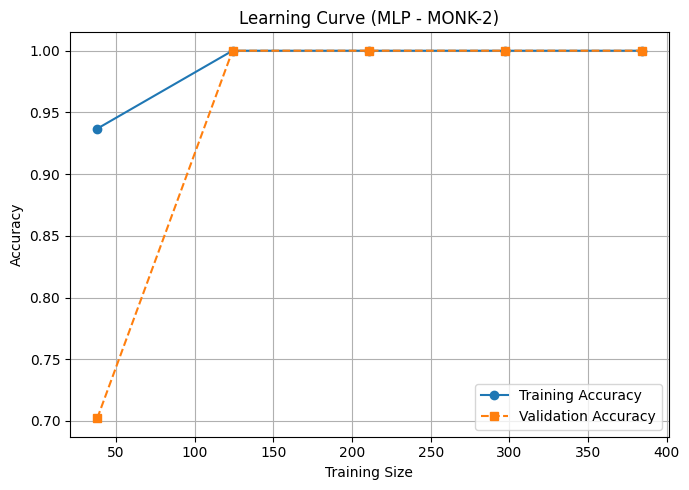

In [18]:
# Use best MLP configuration for MONK-2
mlp2_best = best_mlp2

# Compute learning curve
train_sizes2, train_scores2, val_scores2 = learning_curve(
    mlp2_best,
    X2_train_val, y2_train_val,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Compute mean scores
train_mean2 = train_scores2.mean(axis=1)
val_mean2 = val_scores2.mean(axis=1)

# Plot
plt.figure(figsize=(7, 5))
plt.plot(train_sizes2, train_mean2, marker="o", linestyle="-", label="Training Accuracy")
plt.plot(train_sizes2, val_mean2, marker="s", linestyle="--", label="Validation Accuracy")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve (MLP - MONK-2)")
plt.legend()
plt.grid()

# Save the learning curve figure to the results folder
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "monk2_learning_curve.png"), dpi=300)
plt.show()

### Interpretation

MONK-2 is more difficult than MONK-1 because the target concept depends on more complex logical interactions and includes irrelevant attributes. This increases the effective hypothesis space and makes the task more sensitive to model capacity and hyperparameter choice.

The learning curve shows that performance improves as more data is used, confirming that the model needs enough examples to capture the relevant interactions. Hyperparameter tuning is important here: for SVM, the balance between C and gamma controls underfitting and overfitting; for MLP, the number of hidden units and regularization control the trade-off between capacity and generalization.

## MONK-3 Baseline Experiments
We repeat the same pipeline on MONK-3.

In [19]:
# Split MONK-3
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3_encoded, y3, test_size=0.2, random_state=42, stratify=y3
)

# Train a k-NN classifier on MONK-3 as a simple distance-based baseline
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(X_train3, y_train3)
acc_knn3 = accuracy_score(y_test3, knn3.predict(X_test3))

# Train an SVM with RBF kernel on MONK-3 as a non-linear baseline
svm3 = SVC(kernel='rbf', C=1, gamma='scale')
svm3.fit(X_train3, y_train3)
acc_svm3 = accuracy_score(y_test3, svm3.predict(X_test3))

# Train a small multilayer perceptron on MONK-3 as a neural baseline
mlp3 = MLPClassifier(hidden_layer_sizes=(3,), max_iter=1000, random_state=42)
mlp3.fit(X_train3, y_train3)
acc_mlp3 = accuracy_score(y_test3, mlp3.predict(X_test3))

# Print baseline accuracies for MONK-3
print("MONK-3 k-NN:", acc_knn3)
print("MONK-3 SVM:", acc_svm3)
print("MONK-3 MLP:", acc_mlp3)

# Baseline comparison table for MONK-3
results_monk3 = pd.DataFrame({
    "Model": ["k-NN", "SVM", "MLP"],
    "Train Accuracy": [
        accuracy_score(y_train3, knn3.predict(X_train3)),
        accuracy_score(y_train3, svm3.predict(X_train3)),
        accuracy_score(y_train3, mlp3.predict(X_train3))
    ],
    "Test Accuracy": [
        acc_knn3,
        acc_svm3,
        acc_mlp3
    ],
    "Test F1 Score": [
        f1_score(y_test3, knn3.predict(X_test3), average='weighted'),
        f1_score(y_test3, svm3.predict(X_test3), average='weighted'),
        f1_score(y_test3, mlp3.predict(X_test3), average='weighted')
    ]
})

print(results_monk3)

MONK-3 k-NN: 0.9459459459459459
MONK-3 SVM: 1.0
MONK-3 MLP: 0.972972972972973
  Model  Train Accuracy  Test Accuracy  Test F1 Score
0  k-NN        0.963883       0.945946       0.945972
1   SVM        0.986456       1.000000       1.000000
2   MLP        0.966140       0.972973       0.972986


## MONK-3 Hyperparameter Tuning
We tune k-NN, SVM, and MLP using 5-fold cross-validation.

Best MONK-3 k-NN params: {'n_neighbors': 7}
Best MONK-3 k-NN CV score: 0.9594484167517876
MONK-3 k-NN Train Accuracy: 0.9706546275395034
MONK-3 k-NN Test Accuracy: 0.9819819819819819
Best MONK-3 SVM params: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best MONK-3 SVM CV score: 0.9864402451481104
MONK-3 SVM Train Accuracy: 0.9864559819413092
MONK-3 SVM Test Accuracy: 1.0
Best MONK-3 MLP params: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (2,)}
Best MONK-3 MLP CV score: 0.9864402451481104
MONK-3 MLP Train Accuracy: 0.9864559819413092
MONK-3 MLP Test Accuracy: 1.0


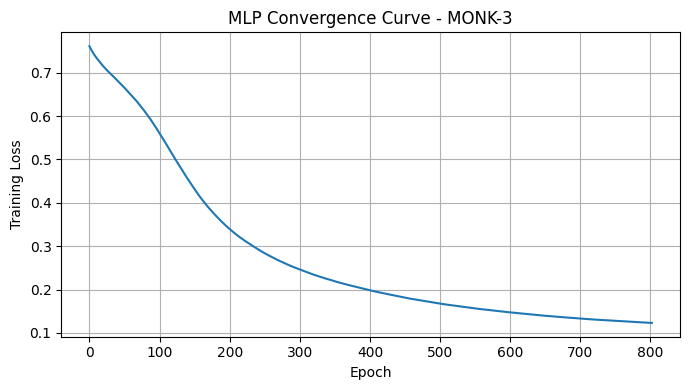

MONK-3 MLP Mean Test Accuracy: 0.9847
MONK-3 MLP Std Test Accuracy: 0.0128
  Model                                    Best Parameters  Best CV Accuracy
0  k-NN                                 {'n_neighbors': 7}          0.959448
1   SVM           {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}          0.986440
2   MLP  {'activation': 'relu', 'alpha': 0.0001, 'hidde...          0.986440
  Model  Train Accuracy  Test Accuracy  Best CV Accuracy  \
0  k-NN        0.970655       0.981982          0.959448   
1   SVM        0.986456       1.000000          0.986440   
2   MLP        0.986456       1.000000          0.986440   

                                     Best Parameters  MLP Mean Test Accuracy  \
0                                 {'n_neighbors': 7}                     NaN   
1           {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}                     NaN   
2  {'activation': 'relu', 'alpha': 0.0001, 'hidde...                0.984685   

   MLP Std Test Accuracy  
0                    NaN  
1

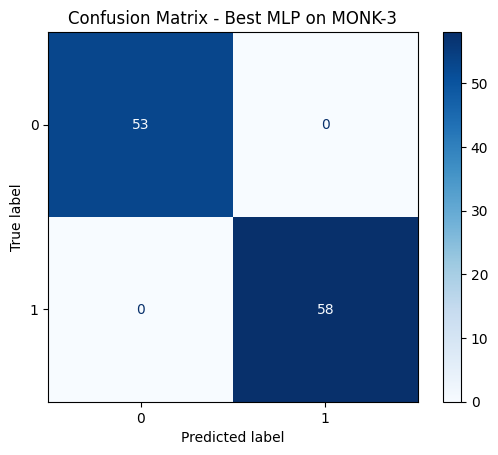

In [20]:
# Hold out final test set before hyperparameter tuning
X3_train_val, X3_test_final, y3_train_val, y3_test_final = train_test_split(
    X3_encoded, y3, test_size=0.2, random_state=42, stratify=y3
)

# ------------------------------------------------------------
# k-NN hyperparameter tuning for MONK-3
# ------------------------------------------------------------
param_grid_knn3 = {
    "n_neighbors": [1, 3, 5, 7, 9]
}

grid_knn3 = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid_knn3,
    cv=5,
    scoring="accuracy"
)

grid_knn3.fit(X3_train_val, y3_train_val)

print("Best MONK-3 k-NN params:", grid_knn3.best_params_)
print("Best MONK-3 k-NN CV score:", grid_knn3.best_score_)

best_knn3 = grid_knn3.best_estimator_

train_acc_knn3 = accuracy_score(y3_train_val, best_knn3.predict(X3_train_val))
test_acc_knn3 = accuracy_score(y3_test_final, best_knn3.predict(X3_test_final))

print("MONK-3 k-NN Train Accuracy:", train_acc_knn3)
print("MONK-3 k-NN Test Accuracy:", test_acc_knn3)


# ------------------------------------------------------------
# SVM hyperparameter tuning for MONK-3
# ------------------------------------------------------------
param_grid_svm3 = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.1, 1],
    "kernel": ["rbf"]
}

grid_svm3 = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid_svm3,
    cv=5,
    scoring="accuracy"
)

grid_svm3.fit(X3_train_val, y3_train_val)

print("Best MONK-3 SVM params:", grid_svm3.best_params_)
print("Best MONK-3 SVM CV score:", grid_svm3.best_score_)

best_svm3 = grid_svm3.best_estimator_

train_acc_svm3 = accuracy_score(y3_train_val, best_svm3.predict(X3_train_val))
test_acc_svm3 = accuracy_score(y3_test_final, best_svm3.predict(X3_test_final))

print("MONK-3 SVM Train Accuracy:", train_acc_svm3)
print("MONK-3 SVM Test Accuracy:", test_acc_svm3)


# ------------------------------------------------------------
# MLP hyperparameter tuning for MONK-3
# ------------------------------------------------------------
param_grid_mlp3 = {
    "hidden_layer_sizes": [(2,), (3,), (4,)],
    "activation": ["logistic", "tanh", "relu"],
    "alpha": [0.0001, 0.001, 0.01, 0.1]
}

grid_mlp3 = GridSearchCV(
    estimator=MLPClassifier(max_iter=2000, random_state=42),
    param_grid=param_grid_mlp3,
    cv=5,
    scoring="accuracy"
)

grid_mlp3.fit(X3_train_val, y3_train_val)

print("Best MONK-3 MLP params:", grid_mlp3.best_params_)
print("Best MONK-3 MLP CV score:", grid_mlp3.best_score_)

best_mlp3 = grid_mlp3.best_estimator_

train_acc_mlp3 = accuracy_score(y3_train_val, best_mlp3.predict(X3_train_val))
test_acc_mlp3 = accuracy_score(y3_test_final, best_mlp3.predict(X3_test_final))

print("MONK-3 MLP Train Accuracy:", train_acc_mlp3)
print("MONK-3 MLP Test Accuracy:", test_acc_mlp3)


# ------------------------------------------------------------
# Epoch-based convergence curve for MONK-3 MLP
# ------------------------------------------------------------
mlp_curve3 = MLPClassifier(
    **grid_mlp3.best_params_,
    max_iter=2000,
    random_state=42
)

mlp_curve3.fit(X3_train_val, y3_train_val)

plt.figure(figsize=(7, 4))
plt.plot(mlp_curve3.loss_curve_)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("MLP Convergence Curve - MONK-3")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "monk3_mlp_convergence_curve.png"), dpi=300)
plt.show()


# ------------------------------------------------------------
# Multiple random initializations for MONK-3 MLP
# ------------------------------------------------------------
seeds = range(10)
mlp_accs3 = []

for seed in seeds:
    mlp_trial = MLPClassifier(
        **grid_mlp3.best_params_,
        max_iter=2000,
        random_state=seed
    )
    mlp_trial.fit(X3_train_val, y3_train_val)
    y_pred_trial = mlp_trial.predict(X3_test_final)
    mlp_accs3.append(accuracy_score(y3_test_final, y_pred_trial))

mlp_mean_acc3 = np.mean(mlp_accs3)
mlp_std_acc3 = np.std(mlp_accs3)

print(f"MONK-3 MLP Mean Test Accuracy: {mlp_mean_acc3:.4f}")
print(f"MONK-3 MLP Std Test Accuracy: {mlp_std_acc3:.4f}")


# ------------------------------------------------------------
# Summary table for MONK-3 tuned models
# ------------------------------------------------------------
tuned_results_monk3 = pd.DataFrame({
    "Model": ["k-NN", "SVM", "MLP"],
    "Best Parameters": [
        grid_knn3.best_params_,
        grid_svm3.best_params_,
        grid_mlp3.best_params_
    ],
    "Best CV Accuracy": [
        grid_knn3.best_score_,
        grid_svm3.best_score_,
        grid_mlp3.best_score_
    ]
})

print(tuned_results_monk3)


# Final evaluation table for MONK-3 tuned models
monk3_tuned_eval = pd.DataFrame({
    "Model": ["k-NN", "SVM", "MLP"],
    "Train Accuracy": [
        train_acc_knn3,
        train_acc_svm3,
        train_acc_mlp3
    ],
    "Test Accuracy": [
        test_acc_knn3,
        test_acc_svm3,
        test_acc_mlp3
    ],
    "Best CV Accuracy": [
        grid_knn3.best_score_,
        grid_svm3.best_score_,
        grid_mlp3.best_score_
    ],
    "Best Parameters": [
        grid_knn3.best_params_,
        grid_svm3.best_params_,
        grid_mlp3.best_params_
    ],
    "MLP Mean Test Accuracy": [
        np.nan,
        np.nan,
        mlp_mean_acc3
    ],
    "MLP Std Test Accuracy": [
        np.nan,
        np.nan,
        mlp_std_acc3
    ]
})

print(monk3_tuned_eval)

# confusion matrix for the best MLP model on MONK-3
y_pred_mlp3 = best_mlp3.predict(X3_test_final)
cm_mlp3 = confusion_matrix(y3_test_final, y_pred_mlp3)
disp_mlp3 = ConfusionMatrixDisplay(confusion_matrix=cm_mlp3)
disp_mlp3.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Best MLP on MONK-3")
plt.savefig(os.path.join(results_dir, "monk3_mlp_confusion_matrix.png"))
plt.show()

On MONK-3, the effect of noisy labels must be considered: the goal is not to memorize every training example, but to learn the underlying rule.

## MONK-3 Learning Curve (MLP)
We analyze how the tuned MLP behaves with increasing training size.

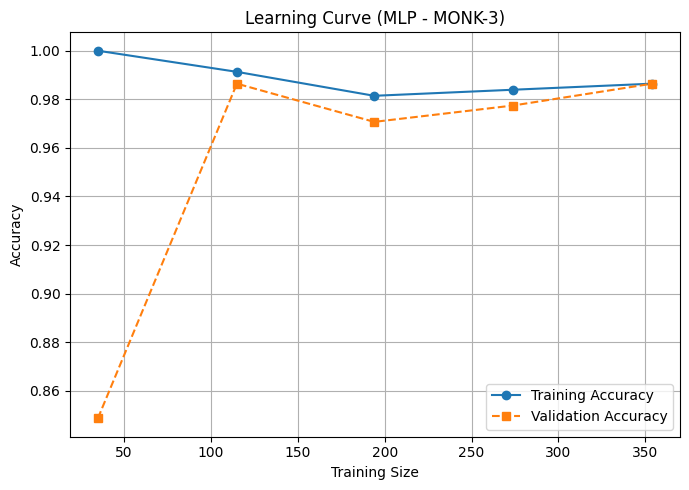

In [21]:
# Use best MLP configuration for MONK-3
mlp3_best = best_mlp3

# Compute learning curve
train_sizes3, train_scores3, val_scores3 = learning_curve(
    mlp3_best,
    X3_train_val, y3_train_val,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

# Compute mean scores
train_mean3 = train_scores3.mean(axis=1)
val_mean3 = val_scores3.mean(axis=1)

# Plot and save
plt.figure(figsize=(7, 5))
plt.plot(train_sizes3, train_mean3, marker="o", linestyle="-", label="Training Accuracy")
plt.plot(train_sizes3, val_mean3, marker="s", linestyle="--", label="Validation Accuracy")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve (MLP - MONK-3)")
plt.legend()
plt.grid()

# Save the learning curve figure to the results folder
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "monk3_learning_curve.png"), dpi=300)
plt.show()

### Interpretation

MONK-3 has moderate rule complexity but also contains noisy labels in the training set. This means that perfect training accuracy is not necessarily desirable: a model that fits every training sample may be memorizing noise rather than learning the underlying rule.

Therefore, the performance is partly noise-limited. If test accuracy is close to or even higher than training accuracy, this is not suspicious; it can indicate that the model is learning the underlying structure while ignoring mislabeled samples. In this task, good generalization is more important than perfect training fit.

The L2 regularization parameter (alpha) helps reduce overfitting to noisy labels by penalizing large weights, which is particularly important in MONK-3.

## Final MONK Summary
We compare the best tuned k-NN, SVM, and MLP results across all three MONK tasks.

In [22]:
final_monk_summary = pd.DataFrame({
    "Task": ["MONK-1", "MONK-2", "MONK-3"],

    "Best k-NN CV Accuracy": [
        grid_knn.best_score_,
        grid_knn2.best_score_,
        grid_knn3.best_score_
    ],

    "Best SVM CV Accuracy": [
        grid_svm.best_score_,
        grid_svm2.best_score_,
        grid_svm3.best_score_
    ],

    "Best MLP CV Accuracy": [
        grid_mlp.best_score_,
        grid_mlp2.best_score_,
        grid_mlp3.best_score_
    ],

    "k-NN Final Test Accuracy": [
        test_acc_knn1,
        test_acc_knn2,
        test_acc_knn3
    ],

    "SVM Final Test Accuracy": [
        test_acc_svm1,
        test_acc_svm2,
        test_acc_svm3
    ],

    "MLP Final Test Accuracy": [
        test_acc_mlp1,
        test_acc_mlp2,
        test_acc_mlp3
    ],

    "MLP Mean Test Accuracy": [
        mlp_mean_acc1,
        mlp_mean_acc2,
        mlp_mean_acc3
    ],

    "MLP Std Test Accuracy": [
        mlp_std_acc1,
        mlp_std_acc2,
        mlp_std_acc3
    ],

    "Best k-NN Parameters": [
        grid_knn.best_params_,
        grid_knn2.best_params_,
        grid_knn3.best_params_
    ],

    "Best SVM Parameters": [
        grid_svm.best_params_,
        grid_svm2.best_params_,
        grid_svm3.best_params_
    ],

    "Best MLP Parameters": [
        grid_mlp.best_params_,
        grid_mlp2.best_params_,
        grid_mlp3.best_params_
    ]
})

print(final_monk_summary)

     Task  Best k-NN CV Accuracy  Best SVM CV Accuracy  Best MLP CV Accuracy  \
0  MONK-1               0.957278              1.000000               1.00000   
1  MONK-2               0.675000              0.995833               1.00000   
2  MONK-3               0.959448              0.986440               0.98644   

   k-NN Final Test Accuracy  SVM Final Test Accuracy  MLP Final Test Accuracy  \
0                  0.991071                      1.0                      1.0   
1                  0.743802                      1.0                      1.0   
2                  0.981982                      1.0                      1.0   

   MLP Mean Test Accuracy  MLP Std Test Accuracy Best k-NN Parameters  \
0                0.858036               0.101287   {'n_neighbors': 9}   
1                0.732231               0.111934   {'n_neighbors': 1}   
2                0.984685               0.012772   {'n_neighbors': 7}   

                           Best SVM Parameters  \
0  {'C': 1,

## Final Discussion

The three MONK tasks show different learning behaviors.

MONK-1 is the easiest task: it is deterministic, low-complexity, and noise-free. Both SVM and MLP are sufficiently expressive, so high accuracy is expected.

MONK-2 is more challenging because it involves more complex feature interactions and irrelevant attributes. This makes hyperparameter tuning more important, since models must have enough capacity to learn the rule without overfitting.

MONK-3 has moderate complexity but includes noisy labels in the training set. For this reason, performance is noise-limited, and perfect training accuracy is not necessarily a good objective. A model that avoids memorizing noisy labels can generalize better.

Overall, SVM performs strongly because the RBF kernel can model nonlinear decision boundaries, while MLP is also effective because even a small neural network can represent the MONK rules. The results confirm that the preprocessing pipeline and model selection procedure are working correctly, while also showing how task complexity and label noise affect generalization.

### Cross-Task Analysis

The three MONK tasks highlight different aspects of learning:

- MONK-1 represents a low-complexity, noise-free setting where both SVM and MLP easily achieve perfect generalization.
- MONK-2 introduces irrelevant features and complex interactions, making model capacity and hyperparameter tuning critical.
- MONK-3 introduces label noise, limiting achievable accuracy and emphasizing generalization over perfect training fit.

From a bias-variance perspective:
- MONK-1 lies in a low-bias, low-variance regime.
- MONK-2 requires careful balance between bias and variance.
- MONK-3 is dominated by noise, where reducing variance (avoiding overfitting) is essential.

These differences explain why similar models behave differently across the three tasks.

### Limitations

The MONK experiments are useful as an implementation and validation benchmark, but good MONK performance alone does not guarantee good performance on the CUP task. The CUP dataset has a different structure, different output type, and a different evaluation metric.

The results may also depend on the random split and model initialization. For this reason, fixed random seeds are used throughout the notebook to make the experiments reproducible.

In [23]:
# Baseline results
results_monk1.to_csv(os.path.join(results_dir, "monk1_baseline.csv"), index=False)
results_monk2.to_csv(os.path.join(results_dir, "monk2_baseline.csv"), index=False)
results_monk3.to_csv(os.path.join(results_dir, "monk3_baseline.csv"), index=False)

# Tuned CV summary results
tuned_results_monk1.to_csv(os.path.join(results_dir, "monk1_tuned.csv"), index=False)
tuned_results_monk2.to_csv(os.path.join(results_dir, "monk2_tuned.csv"), index=False)
tuned_results_monk3.to_csv(os.path.join(results_dir, "monk3_tuned.csv"), index=False)

# Final evaluation tables
monk1_tuned_eval.to_csv(os.path.join(results_dir, "monk1_tuned_eval.csv"), index=False)
monk2_tuned_eval.to_csv(os.path.join(results_dir, "monk2_tuned_eval.csv"), index=False)
monk3_tuned_eval.to_csv(os.path.join(results_dir, "monk3_tuned_eval.csv"), index=False)

# Final summary
final_monk_summary.to_csv(os.path.join(results_dir, "final_monk_summary.csv"), index=False)

print("All MONK result tables saved successfully.")

All MONK result tables saved successfully.
